softmax classifier, from cs231n-2016-winter

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import CIFAR10

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 1

plt.rcParams['figure.figsize'] = (20.0, 16.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

In [3]:
def load_cifar10_numpy(root="cs231n/datasets"):
    tr = CIFAR10(root=root, train=True,  download=True)
    te = CIFAR10(root=root, train=False, download=True)

    Xtr = np.array(tr.data, dtype=np.float32)   # (50000, 32, 32, 3), uint8 -> float32
    Ytr = np.array(tr.targets, dtype=np.int64)  # (50000,)
    Xte = np.array(te.data, dtype=np.float32)   # (10000, 32, 32, 3)
    Yte = np.array(te.targets, dtype=np.int64)  # (10000,)
    return Xtr, Ytr, Xte, Yte

X_train, y_train, X_test, y_test = load_cifar10_numpy()

num_training=49000
num_validation=1000
num_test=1000
num_dev=500
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

print('============================================')
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

/Users/mxz/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training data shape:  (49000, 32, 32, 3)
Training labels shape:  (49000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


In [4]:
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# Normalize the data: subtract the mean image
mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# add bias dimension and transform into columns
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

In [5]:
def softmax_loss_vectorized(W, X, y, reg):
    """
    Softmax loss function, vectorized version.

    Inputs and outputs are the same as softmax_loss_naive.
    """
    loss = 0.0
    dW = np.zeros_like(W)

    N = X.shape[0]
    logits = X @ W
    logits -= np.max(logits, axis=1, keepdims=True)  # 🧙‍♂️
    probs = np.exp(logits) / np.sum(np.exp(logits), 1)[:, None]
    y_probs = probs[np.arange(N), y]
    loss = -np.log(y_probs)
    loss = loss.sum() / N
    loss += 0.5 * reg * np.sum(W * W)

    dL_dprobs_y = -1 / y_probs
    dL_dprobs = np.zeros_like(probs)
    dL_dprobs[np.arange(probs.shape[0]), y] = dL_dprobs_y
    # todo -- to understand fockin probs.copy thing here
    dL_dlogits = probs.copy()
    dL_dlogits[np.arange(probs.shape[0]), y] -= 1

    dW += X.T @ dL_dlogits
    dW /= N
    dW += reg * W

    return loss, dW


In [6]:
class LinearClassifier(object):

    def __init__(self):
        self.W = None

    def train(self, X, y, learning_rate=1e-3, reg=1e-5, num_iters=100,
              batch_size=64, verbose=False):
        """
        Train this linear classifier using stochastic gradient descent.

        Inputs:
        - X: A numpy array of shape (N, D) containing training data; there are N
          training samples each of dimension D.
        - y: A numpy array of shape (N,) containing training labels; y[i] = c
          means that X[i] has label 0 <= c < C for C classes.
        - learning_rate: (float) learning rate for optimization.
        - reg: (float) regularization strength.
        - num_iters: (integer) number of steps to take when optimizing
        - batch_size: (integer) number of training examples to use at each step.
        - verbose: (boolean) If true, print progress during optimization.

        Outputs:
        A list containing the value of the loss function at each training iteration.
        """
        num_train, dim = X.shape
        # assume y takes values 0...K-1 where K is number of classes
        num_classes = np.max(y) + 1
        if self.W is None:
            # lazily initialize W
            self.W = 0.0001 * np.random.randn(dim, num_classes)

        # Run stochastic gradient descent to optimize W
        loss_history = []
        n_samples = y.shape[0]
        assert y.shape[0] == X.shape[0]

        for it in range(num_iters):
            random_idx = np.random.choice(n_samples, batch_size, replace=True)
            X_batch = X[random_idx]
            y_batch = y[random_idx]

            # evaluate loss and gradient
            loss, grad = self.loss(X_batch, y_batch, reg)
            loss_history.append(loss)

            self.W += -grad * learning_rate

            if verbose and it % 500 == 0:
                print('iteration %d / %d: loss %f' % (it, num_iters, loss))

        return loss_history

    def softmax(self, X):
        scores = X @ self.W
        scores -= np.max(scores, axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        return probs

    def predict(self, X):
        """
        Use the trained weights of this linear classifier to predict labels for
        data points.

        Inputs:
        - X: N x D array of training data. Each column is a D-dimensional point.

        Returns:
        - y_pred: Predicted labels for the data in X. y_pred is a 1-dimensional
          array of length N, and each element is an integer giving the predicted
          class.
        """
        preds = self.softmax(X)
        y_pred = np.argmax(preds, axis=1)
        return y_pred


"""
Compute the loss function and its derivative.
Subclasses will override this.

Inputs:
- X_batch: A numpy array of shape (N, D) containing a minibatch of N
    data points; each point has dimension D.
- y_batch: A numpy array of shape (N,) containing labels for the minibatch.
- reg: (float) regularization strength.

Returns: A tuple containing:
- loss as a single float
- gradient with respect to self.W; an array of the same shape as W
"""


class Softmax(LinearClassifier):
    """ A subclass that uses the Softmax + Cross-entropy loss function """

    def loss(self, X_batch, y_batch, reg):
        return softmax_loss_vectorized(self.W, X_batch, y_batch, reg)

In [7]:
best_val = -1
best_params = (None, None)
learning_rates = [6.5e-7, 7e-7, 7.5e-7,]
regularization_strengths = [1e2, 2e2, 4e2, 4.5e2, 5e2, 5.5e2, 6e2]


for lr in learning_rates:
    for rs in regularization_strengths:
        classifier = Softmax()
        loss = classifier.train(
            X_train, y_train, learning_rate=lr, reg=rs, num_iters=1500)

        y_val_pred = classifier.predict(X_val)
        print('validation accuracy: %f' %
              (val_acc := np.mean(y_val == y_val_pred), ), 'with params: ', lr, rs)

        if val_acc > best_val:
            best_val = val_acc
            best_params = (lr, rs)

print('best validation accuracy achieved during cross-validation: %f' %
      best_val, 'best params', best_params)

validation accuracy: 0.403000 with params:  6.5e-07 100.0
validation accuracy: 0.388000 with params:  6.5e-07 200.0
validation accuracy: 0.402000 with params:  6.5e-07 400.0
validation accuracy: 0.390000 with params:  6.5e-07 450.0
validation accuracy: 0.417000 with params:  6.5e-07 500.0
validation accuracy: 0.409000 with params:  6.5e-07 550.0
validation accuracy: 0.396000 with params:  6.5e-07 600.0
validation accuracy: 0.388000 with params:  7e-07 100.0
validation accuracy: 0.408000 with params:  7e-07 200.0
validation accuracy: 0.413000 with params:  7e-07 400.0
validation accuracy: 0.408000 with params:  7e-07 450.0
validation accuracy: 0.398000 with params:  7e-07 500.0
validation accuracy: 0.370000 with params:  7e-07 550.0
validation accuracy: 0.400000 with params:  7e-07 600.0
validation accuracy: 0.404000 with params:  7.5e-07 100.0
validation accuracy: 0.397000 with params:  7.5e-07 200.0
validation accuracy: 0.382000 with params:  7.5e-07 400.0
validation accuracy: 0.39800

In [8]:
(lr, rs) = best_params
best_softmax = Softmax()
best_softmax.train(
    X_train, y_train, learning_rate=lr, reg=rs, num_iters=50000, verbose=True)

# evaluate on test set
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('softmax on raw pixels final test set accuracy: %f' % (test_accuracy, ))

iteration 0 / 50000: loss 2.438855
iteration 500 / 50000: loss 2.014723
iteration 1000 / 50000: loss 1.634960
iteration 1500 / 50000: loss 1.729445
iteration 2000 / 50000: loss 1.772421
iteration 2500 / 50000: loss 1.825849
iteration 3000 / 50000: loss 1.871801
iteration 3500 / 50000: loss 1.675507
iteration 4000 / 50000: loss 1.931751
iteration 4500 / 50000: loss 1.638045
iteration 5000 / 50000: loss 1.791345
iteration 5500 / 50000: loss 1.824486
iteration 6000 / 50000: loss 1.776299
iteration 6500 / 50000: loss 1.761432
iteration 7000 / 50000: loss 1.694216
iteration 7500 / 50000: loss 1.597386
iteration 8000 / 50000: loss 1.806826
iteration 8500 / 50000: loss 1.803608
iteration 9000 / 50000: loss 1.807063
iteration 9500 / 50000: loss 1.773711
iteration 10000 / 50000: loss 1.806856
iteration 10500 / 50000: loss 1.735889
iteration 11000 / 50000: loss 1.657234
iteration 11500 / 50000: loss 1.782210
iteration 12000 / 50000: loss 1.864476
iteration 12500 / 50000: loss 1.868632
iteration 

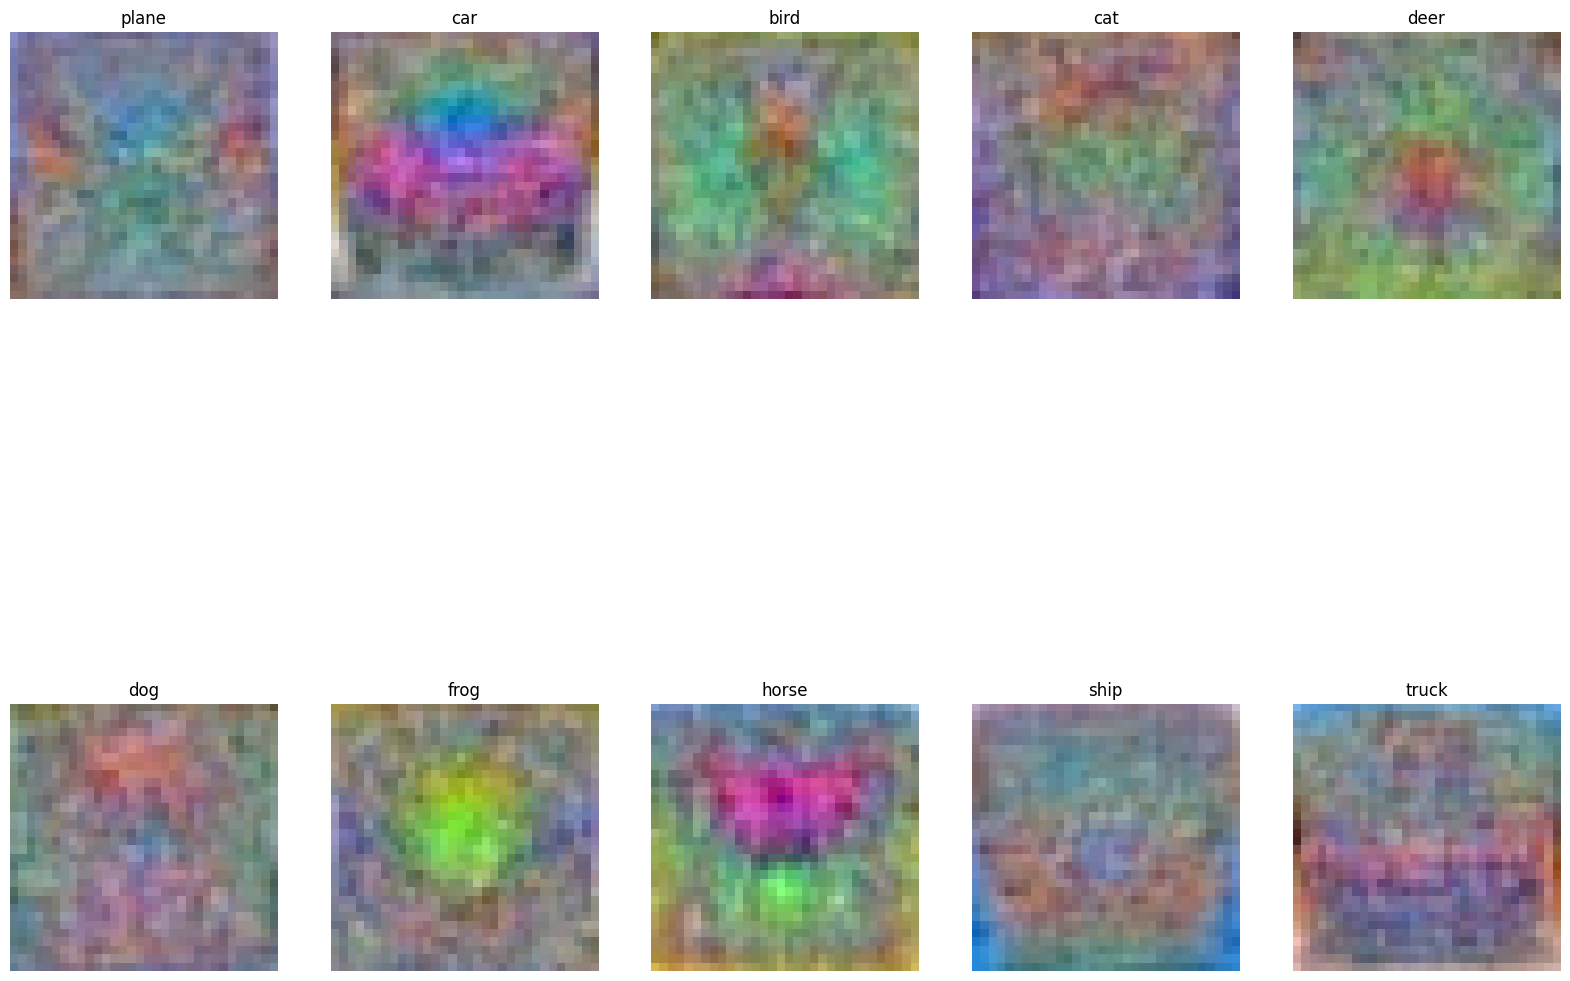

In [9]:
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)

w_min, w_max = np.min(w), np.max(w)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
  plt.subplot(2, 5, i + 1)
  
  # Rescale the weights to be between 0 and 255
  wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
  plt.imshow(wimg.astype('uint8'))
  plt.axis('off')
  plt.title(classes[i])